In [ ]:
from glob import glob
import json
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel, wilcoxon

# Baseline Table Creation

In [108]:
results = [res for res in glob("../logs/train/runs/*/efficientnet/*/finalmetrics.json") if "DataS1" not in res]
results

['../logs/train/runs/HSN/efficientnet/2026-08-01_142755/finalmetrics.json',
 '../logs/train/runs/HSN/efficientnet/2026-08-01_151103/finalmetrics.json',
 '../logs/train/runs/SNE/efficientnet/2026-08-02_013609/finalmetrics.json',
 '../logs/train/runs/POW/efficientnet/2026-08-01_204510/finalmetrics.json',
 '../logs/train/runs/PER/efficientnet/2026-08-01_233812/finalmetrics.json',
 '../logs/train/runs/NES/efficientnet/2026-08-01_182656/finalmetrics.json',
 '../logs/train/runs/UHH/efficientnet/2026-08-02_065114/finalmetrics.json',
 '../logs/train/runs/NBP/efficientnet/2026-08-01_161842/finalmetrics.json',
 '../logs/train/runs/SSW/efficientnet/2026-08-02_034156/finalmetrics.json']

In [ ]:
metrics = {}

for filepath in results:
    dataset_name = filepath.split("/")[4]
    with open(filepath) as f:
        metric = json.load(f)
        metrics[dataset_name] = {m["name"]:m["value"] for m in metric}

In [111]:
pd.DataFrame.from_dict(metrics).loc[["test/cmAP", "test/MultilabelAUROC", "test/T1Accuracy"], ["POW", "PER", "NES", "UHH", "HSN", "NBP", "SSW", "SNE"]]   \
                               .rename(index=lambda x: x.split("/")[-1]).to_csv("baseline.csv")

# ArcticBirdSounds

In [84]:
# get overall results, excluding ablation run
results = [res for res in glob("../logs/train/runs/DataS1/efficientnet/*/finalmetrics.json") if "2026-08-03_011907" not in res]
results

['../logs/train/runs/DataS1/efficientnet/2026-08-03_020046/finalmetrics.json',
 '../logs/train/runs/DataS1/efficientnet/2026-08-03_024456/finalmetrics.json',
 '../logs/train/runs/DataS1/efficientnet/2026-08-03_035244/finalmetrics.json',
 '../logs/train/runs/DataS1/efficientnet/2026-08-03_031850/finalmetrics.json',
 '../logs/train/runs/DataS1/efficientnet/2026-08-03_000655/finalmetrics.json']

In [ ]:
metrics = {}

for i in range(len(results)):
    filepath = results[i]
    dataset_name = filepath.split("/")[4]
    with open(filepath) as f:
        metric = json.load(f)
        metrics[i] = {m["name"]:m["value"] for m in metric}

seed_res = pd.DataFrame.from_dict(metrics).loc[["test/cmAP", "test/MultilabelAUROC", "test/T1Accuracy", "test/T3Accuracy"]]   \
                                          .rename(index=lambda x: x.split("/")[-1])

seed_res.to_csv("datas1_res.csv")

In [86]:
seed_res

,0,1,2,3,4
cmAP,0.245870,0.230353,0.227117,0.250707,0.228426
MultilabelAUROC,0.763231,0.765964,0.759374,0.780376,0.776064
T1Accuracy,0.393658,0.354580,0.385650,0.352979,0.315823
T3Accuracy,0.604420,0.570788,0.594811,0.542601,0.466368


## Overall Metrics

In [88]:
mean_std = pd.concat([seed_res.mean(axis=1), seed_res.std(axis=1)], axis=1)
mean_std

,0,1
cmAP,0.236495,0.010962
MultilabelAUROC,0.769002,0.008867
T1Accuracy,0.360538,0.030901
T3Accuracy,0.555798,0.055414


## Ablation

In [89]:
ablation_files = [res for res in glob("../logs/ablation/runs/DataS1/efficientnet/*/finalmetrics.json")]
ablation_files

['../logs/ablation/runs/DataS1/efficientnet/2026-08-12_192658/finalmetrics.json',
 '../logs/ablation/runs/DataS1/efficientnet/2026-08-12_193056/finalmetrics.json',
 '../logs/ablation/runs/DataS1/efficientnet/2026-08-12_193207/finalmetrics.json',
 '../logs/ablation/runs/DataS1/efficientnet/2026-08-12_192944/finalmetrics.json',
 '../logs/ablation/runs/DataS1/efficientnet/2026-08-12_192834/finalmetrics.json']

In [90]:
ablation_metrics = {}

for i in range(len(ablation_files)):
    filepath = ablation_files[i]
    dataset_name = filepath.split("/")[4]
    with open(filepath) as f:
        metric = json.load(f)
        ablation_metrics[i] = {m["name"]:m["value"] for m in metric}

ablation_res = pd.DataFrame.from_dict(ablation_metrics).loc[["test/cmAP", "test/MultilabelAUROC", "test/T1Accuracy", "test/T3Accuracy"]]   \
                                          .rename(index=lambda x: x.split("/")[-1])
ablation_res

,0,1,2,3,4
cmAP,0.018437,0.020455,0.024664,0.018412,0.022316
MultilabelAUROC,0.466039,0.495045,0.483324,0.415947,0.503766
T1Accuracy,0.028507,0.048366,0.014094,0.000641,0.002883
T3Accuracy,0.068225,0.106662,0.115951,0.108905,0.021140


In [91]:
seed_mean = seed_res.mean(axis=1)
seed_std = seed_res.std(axis=1)

ablation_mean = ablation_res.mean(axis=1)
ablation_std = ablation_res.std(axis=1)

metrics_table = []

for metric, mean, std, amean, astd in zip(["cmAP", "MultilabelAUROC", "T1Accuracy"], seed_mean, seed_std, ablation_mean, ablation_std):
    metrics_table.append([metric, f"{mean:.2f} ± {std:.2f}", f"{amean:.2f} ± {astd:.2f}"])
metrics_table

[['cmAP', '0.24 ± 0.01', '0.02 ± 0.00'],
 ['MultilabelAUROC', '0.77 ± 0.01', '0.47 ± 0.03'],
 ['T1Accuracy', '0.36 ± 0.03', '0.02 ± 0.02']]

## Significance Testing

In [ ]:

ttest_res = {}

for metric in ["cmAP", "MultilabelAUROC", "T1Accuracy"]:
    ttest_res[metric] = ttest_rel(seed_res.loc[metric].values, ablation_res.loc[metric].values)

In [94]:
ttest_res

{'cmAP': TtestResult(statistic=36.08542677395039, pvalue=3.520494519013809e-06, df=4),
 'MultilabelAUROC': TtestResult(statistic=16.723953115432074, pvalue=7.49055476967462e-05, df=4),
 'T1Accuracy': TtestResult(statistic=25.320994475816754, pvalue=1.4445277656784737e-05, df=4)}

## Secondary Analyses

In [96]:
# get per sample results, excluding ablation run
results = [res for res in glob("../logs/train/runs/DataS1/efficientnet/*/test_predictions.csv") if "2026-08-03_011907" not in res]
results

['../logs/train/runs/DataS1/efficientnet/2026-08-03_020046/test_predictions.csv',
 '../logs/train/runs/DataS1/efficientnet/2026-08-03_024456/test_predictions.csv',
 '../logs/train/runs/DataS1/efficientnet/2026-08-03_035244/test_predictions.csv',
 '../logs/train/runs/DataS1/efficientnet/2026-08-03_031850/test_predictions.csv',
 '../logs/train/runs/DataS1/efficientnet/2026-08-03_000655/test_predictions.csv']

In [97]:
seed_res_dfs = []
for i in range(len(results)):
    seed = i+1
    df = pd.read_csv(results[i])
    df["year"] = df["filepath"].apply(lambda x: x.split("/")[-1].split("_")[0])
    df["recording_site"] = df["filepath"].apply(lambda x: x.split("/")[-1].split("_")[1])
    df["seed"] = seed
    seed_res_dfs.append(df)

all_res = pd.concat(seed_res_dfs).dropna()
all_res["true_labels"] = all_res["true_labels"].apply(lambda x: set([int(x)]) if "," not in x else set([int(y) for y in x.split(",")]))
all_res

,filepath,predicted_label,confidence,true_labels,year,recording_site,seed
0,/scratch0/gbarthol/comp0173/BirdSet/data/DataS...,11,0.491943,{11},2018,CORI-1,1
2,/scratch0/gbarthol/comp0173/BirdSet/data/DataS...,7,0.540039,{11},2018,CORI-1,1
10,/scratch0/gbarthol/comp0173/BirdSet/data/DataS...,14,0.890625,{1},2018,CORI-1,1
11,/scratch0/gbarthol/comp0173/BirdSet/data/DataS...,14,0.797852,{1},2018,CORI-1,1
13,/scratch0/gbarthol/comp0173/BirdSet/data/DataS...,9,0.463379,{10},2018,CORI-1,1
...,...,...,...,...,...,...,...
6074,/scratch0/gbarthol/comp0173/BirdSet/data/DataS...,8,0.301270,{8},2019,ZACK-1,5
6077,/scratch0/gbarthol/comp0173/BirdSet/data/DataS...,8,0.812500,{8},2019,ZACK-1,5
6082,/scratch0/gbarthol/comp0173/BirdSet/data/DataS...,8,0.951172,{8},2019,ZACK-1,5
6083,/scratch0/gbarthol/comp0173/BirdSet/data/DataS...,8,0.983887,{8},2019,ZACK-1,5


### Species Accuracy

In [99]:
per_seed_species_data = []

per_seed_species_acc = []
per_seed_species_std = []

per_seed_conf_matrix = np.ndarray((5,31,31))

for seed in range(1,6):
    df = all_res[all_res["seed"]==seed].explode("true_labels")
    df["accuracy"] = df.apply(lambda x: x["predicted_label"] == x["true_labels"], axis=1).astype(int)
    species_accuracy = df.groupby(by="true_labels")["accuracy"].mean()
    species_std = df.groupby(by="true_labels")["accuracy"].std()
    per_seed_species_acc.append(species_accuracy)
    per_seed_species_std.append(species_std)
    per_seed_species_data.append(df)

    for idx, data in df.iterrows():
        per_seed_conf_matrix[seed-1,data["predicted_label"],data["true_labels"]] += 1

In [100]:
## class imbalance
species_counts = per_seed_species_data[0]["true_labels"].value_counts()
species_frac = species_counts/species_counts.sum()
species_frac

true_labels
11    0.363583
20    0.107783
8     0.096916
19    0.088399
25    0.069016
0     0.049046
16    0.041410
5     0.022907
30    0.019383
1     0.017621
13    0.015272
10    0.014978
23    0.010866
26    0.010279
4     0.009692
14    0.009104
6     0.008517
18    0.006167
27    0.004993
28    0.004699
7     0.004699
9     0.004405
12    0.003818
21    0.003818
24    0.003818
29    0.002937
17    0.002643
22    0.001762
15    0.000881
3     0.000294
2     0.000294
Name: count, dtype: float64

In [ ]:
with open("/home/gil/comp0173/BirdSet/resources/ebird_codes/DataS1_ebird_codes.json") as f:
    ebird_codes = json.load(f)

In [102]:
# calculate pielou's evenness index
-sum(species_frac * np.log(species_frac))/np.log(31)

0.6840680374793852

### Plots

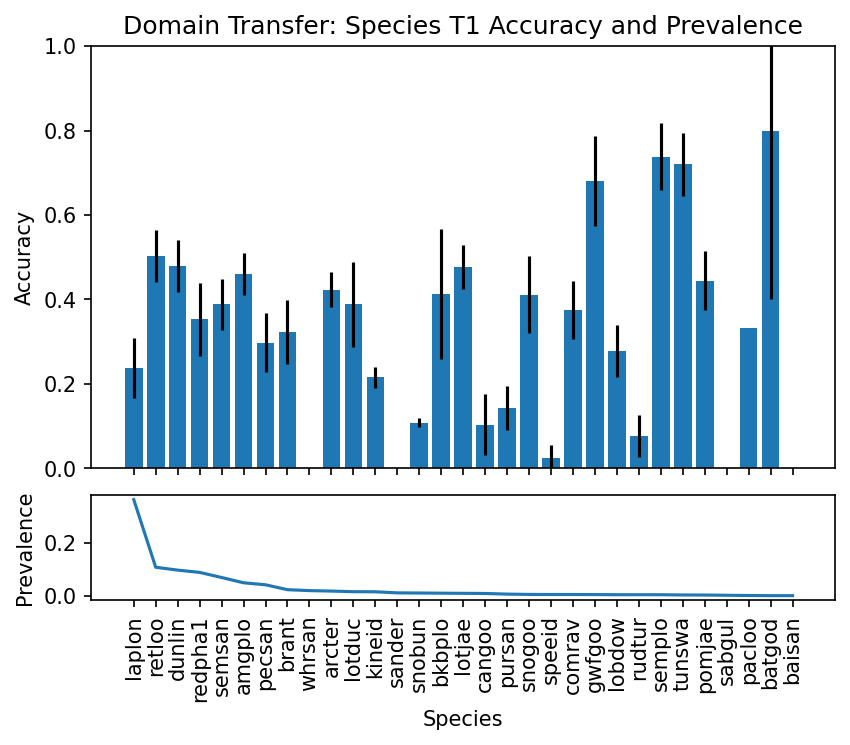

In [104]:
# species accuracy
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, gridspec_kw={"hspace": 0.1}, height_ratios=[4,1])
ax1.bar(np.array(list(ebird_codes["id2label"].values()))[species_frac.index.values.astype(int)], np.mean(per_seed_species_acc, axis=0)[species_frac.index.values.astype(int)], 
       yerr=np.std(per_seed_species_acc, axis=0)[species_frac.index.values.astype(int)])
ax1.set_ylim([0,1])
ax2.plot(species_frac.values)
ax2.tick_params("x", rotation=90)
ax1.set_ylabel("Accuracy")
ax2.set_ylabel("Prevalence")
ax2.set_xlabel("Species")
ax1.set_title("Domain Transfer: Species T1 Accuracy and Prevalence")
fig.set_dpi(150)

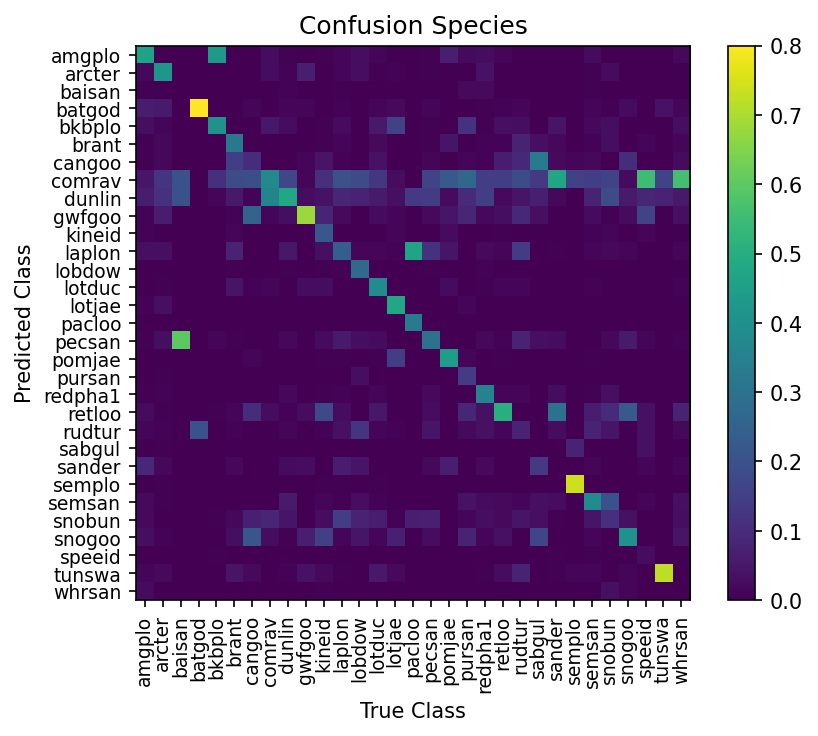

In [105]:
# confusion species
conf_matrix = per_seed_conf_matrix.sum(axis=0)
conf_matrix = conf_matrix / conf_matrix.sum(axis=0)

fig, ax = plt.subplots()
im = ax.imshow(conf_matrix)
ax.figure.colorbar(im, ax=ax)
ax.set_ylabel("Predicted Class")
ax.set_xlabel("True Class")
ax.set_xticks(range(conf_matrix.shape[0]), list(np.array(list(ebird_codes["id2label"].values()))))
ax.tick_params("x", rotation=90)
ax.set_yticks(range(conf_matrix.shape[0]), list(np.array(list(ebird_codes["id2label"].values()))))
ax.set_title("Confusion Species")
ax.tick_params("both", labelsize=9)
fig.set_dpi(150)